# Assignment Sesi 13
Nama: Faraday Barr Fatahillah

Instruksi\
Anda kembali berperan sebagai data analyst di jaringan restoran yang sama dari Assignment Sesi 11. Kali ini, manajer SDM ingin tahu apakah ada perbedaan tip yang dapat dibuktikan secara statistik antara kelompok pelanggan, sebelum merancang kebijakan baru insentif staf.

In [45]:
#Load Dataset
import seaborn as sns

df = sns.load_dataset('tips')

**Task 1 — Uji hipotesis: perbedaan tip perokok vs non-perokok**\
Rumuskan hipotesis:
1. H0: Rata-rata tip pelanggan perokok sama dengan rata-rata tip pelanggan non-perokok.
2. H1: Rata-rata tip pelanggan perokok berbeda dari rata-rata tip pelanggan non-perokok.
 
Lakukan:
1. Pisahkan data tip menjadi dua kelompok: perokok (smoker = Yes) dan non-perokok (smoker = No).
2. Cek normalitas tiap kelompok menggunakan Shapiro-Wilk test (scipy.stats.shapiro). Cetak p-value dan simpulkan apakah data berdistribusi normal pada alpha = 0.05.
3. Berdasarkan hasil uji normalitas, pilih uji yang tepat:     - Jika keduanya normal: gunakan independent samples t-test (scipy.stats.ttest_ind)    - Jika salah satu tidak normal: gunakan Mann-Whitney U test (scipy.stats.mannwhitneyu) Cetak statistik uji dan p-value.
4. Tulis kesimpulan di markdown: pada tingkat kepercayaan 95% (alpha = 0.05), apakah ada perbedaan tip yang signifikan antara perokok dan non-perokok? Apa implikasinya bagi kebijakan restoran?

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

#Task 1.1
smoker = df[df['smoker'] == 'Yes']['tip']
non_smoker = df[df['smoker'] == 'No']['tip']

smoker

56     3.00
58     1.76
60     3.21
61     2.00
62     1.98
       ... 
234    3.00
236    1.00
237    1.17
240    2.00
241    2.00
Name: tip, Length: 93, dtype: float64

In [47]:
non_smoker

0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
235    1.25
238    4.67
239    5.92
242    1.75
243    3.00
Name: tip, Length: 151, dtype: float64

In [48]:
#Task 1.2
stat1, pvalue1 = stats.shapiro(smoker)
stat2, pvalue2 = stats.shapiro(non_smoker)

print(f'p-value Smoker: {pvalue1:.10f}')
print(f'p-value Non Smoker: {pvalue2:.10f}')

p-value Smoker: 0.0000003613
p-value Non Smoker: 0.0000000206


In [49]:
print(f'Normalitas Smoker: {'normal' if pvalue1 > 0.05 else 'tidak normal'}')
print(f'Normalitas Non-Smoker: {'normal' if pvalue2 > 0.05 else 'tidak normal'}')

Normalitas Smoker: tidak normal
Normalitas Non-Smoker: tidak normal


In [50]:
stat, p = stats.mannwhitneyu(smoker, non_smoker)

print(f'p-value Mann Whitney U Test: {p}')

p-value Mann Whitney U Test: 0.7919240198382322


**#Task 1.3**\
Answer:\
Sesuai dengan hasil uji normalitas di atas, dapat dilihat bahwa tidak ditemukan perbedaan antara tip yang diberikan perokok maupun non perokok. Probabilitas perbedaan yang terlihat terjadi karena hanya kebetulan sangat tinggi, sehingga belum ada bukti yang cukup untuk mengatakan bahwa kedua kelompok benar-benar berbeda.\


Implikasi:\
Restoran tidak perlu membuat kebijakan khusus terkait perokok atau non-perokok untuk memberikan tip, karena keduanya menunjukkan perilaku yang sama.


**Task 2 — Uji hipotesis: perbedaan tip makan siang vs makan malam**\
Rumuskan hipotesis:
1. H0: Rata-rata tip saat Dinner sama dengan rata-rata tip saat Lunch.
2. H1: Rata-rata tip saat Dinner lebih tinggi dari rata-rata tip saat Lunch (uji satu arah).
 
Lakukan:
1. Pisahkan data berdasarkan kolom time: Dinner dan Lunch.
2. Buat boxplot yang membandingkan distribusi tip untuk Dinner dan Lunch dalam satu figure. Tambahkan judul, label axis.
3. Jalankan independent samples t-test (atau Mann-Whitney jika data tidak normal, sesuai hasil Task 1). Untuk uji satu arah, gunakan parameter alternative='greater' pada ttest_ind atau mannwhitneyu.
4. Tulis kesimpulan: apakah data mendukung hipotesis bahwa tip saat makan malam lebih tinggi? Sertakan angka rata-rata tip untuk masing-masing waktu makan dalam kesimpulan.

In [51]:
#Task 2.1
dinner = df[df['time'] == 'Dinner']['tip']
lunch = df[df['time'] == 'Lunch']['tip']

dinner

0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
239    5.92
240    2.00
241    2.00
242    1.75
243    3.00
Name: tip, Length: 176, dtype: float64

In [52]:
lunch

77     4.00
78     3.00
79     2.71
80     3.00
81     3.40
       ... 
222    1.92
223    3.00
224    1.58
225    2.50
226    2.00
Name: tip, Length: 68, dtype: float64

In [53]:
print(f'Rata-rata tip lunch: {lunch.mean()}')
print(f'Rata-rata tip dinner: {dinner.mean()}')

Rata-rata tip lunch: 2.728088235294118
Rata-rata tip dinner: 3.102670454545454


C:\Users\bobe\AppData\Local\Temp\ipykernel_35704\1463454895.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='time', y='tip', data=df, palette='Blues')


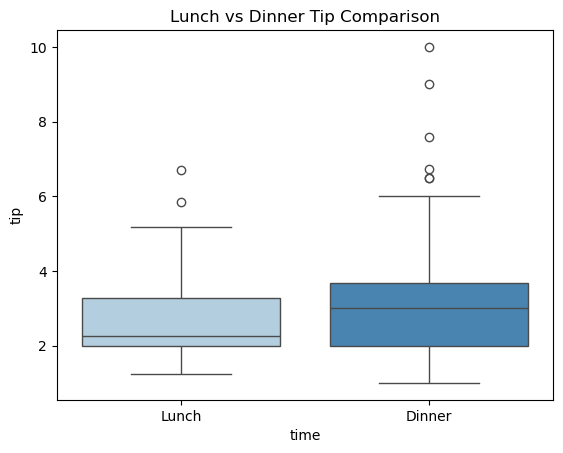

In [54]:
#Task 2.2
sns.boxplot(x='time', y='tip', data=df, palette='Blues')
plt.title('Lunch vs Dinner Tip Comparison')
plt.show()

In [55]:
#Task 2.3
stat_2, p_2 = stats.mannwhitneyu(dinner, lunch, alternative='greater')

print("p-value:", p_2)

p-value: 0.014414022838396583


**#Task 2.4**\
Answer:\
Dapat dilihat bahwa tip makan malam secara signifikan lebih tinggi dibanding dengan makan siang. Probabilitas perbedaan ini kebetulan sangat kecil sehingga dapat disimpulkan bahwa waktu makan malam berpengaruh pada besarnya nominal tip yang diberikan.

Implikasi:\
Restoran dapat mempertimbangkan untuk meningkatkan kualitas layanan dan staff pada malam hari karena memiliki potensi mendapatkan tip lebih tinggi. 

**Task 3 — Analisis korelasi**
1. Hitung korelasi Pearson antara total_bill dan tip menggunakan scipy.stats.pearsonr. Cetak koefisien korelasi (r) dan p-value.
2. Hitung juga korelasi Spearman antara total_bill dan tip menggunakan scipy.stats.spearmanr. Bandingkan nilainya dengan korelasi Pearson.
3. Buat scatter plot total_bill vs tip. Tambahkan garis regresi menggunakan sns.regplot(). Tulis di markdown: seberapa kuat hubungan antara tagihan dan tip? Apakah korelasi tersebut signifikan secara statistik?
4. Hitung korelasi Pearson antara size (jumlah orang dalam rombongan) dan tip. Apakah rombongan yang lebih besar cenderung memberi tip lebih banyak? Sertakan p-value dalam kesimpulan.

In [56]:
#Task 3.1
rvalue_pearson, pvalue_pearson = stats.pearsonr(df['total_bill'], df['tip'])

print(f'Koefisien korelasi pearson (r): {rvalue_pearson}\nP-value korelasi pearson: {pvalue_pearson}')

Koefisien korelasi pearson (r): 0.6757341092113647
P-value korelasi pearson: 6.69247064686336e-34


In [57]:
#Task 3.2
rvalue_spearman, pvalue_spearman = stats.spearmanr(df['total_bill'], df['tip'])
print(f'Koefisien korelasi spearman (r): {rvalue_spearman}\nP-value korelasi spearman: {pvalue_spearman}')

Koefisien korelasi spearman (r): 0.6789681219001009
P-value korelasi spearman: 2.5011584409235997e-34


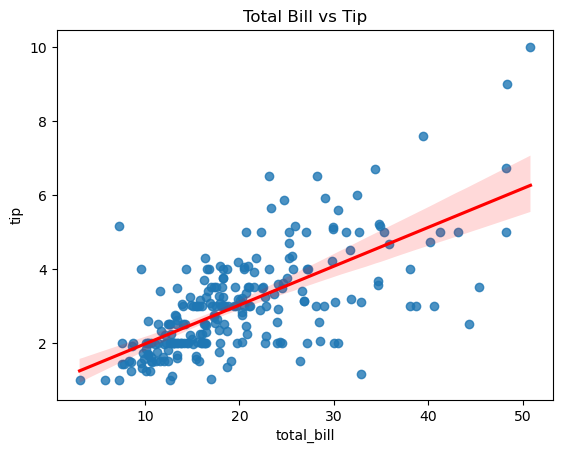

In [58]:
#Task 3.3
sns.regplot(x='total_bill', y='tip', data=df, line_kws={'color': 'red'})
plt.title('Total Bill vs Tip')
plt.show()

Answer:\
Dapat dilihat pada scatter plot di atas bahwa semakin besar total bill semakin besar juga tip yang diberikan. Hal ini dapat dilihat dari garis regresi berwarna merah membantu pernyataan tersebut. Namun, penyebaran data yang masih cukup lebar menunjukkan bahwa ada faktor lain yang mempengaruhi variasi tip pada nilai tagihan yang sama.

In [59]:
#Task 3.4
rvalue_pearsonsize, pvalue_pearsonsize = stats.pearsonr(df['size'], df['tip'])

print(f'Koefisien korelasi pearson (r) ukuran rombongan: {rvalue_pearsonsize}\nP-value korelasi pearson ukuran rombongan: {pvalue_pearsonsize}')

Koefisien korelasi pearson (r) ukuran rombongan: 0.48929877523035725
P-value korelasi pearson ukuran rombongan: 4.3005433272250085e-16


**Task 4 — Ringkasan untuk manajemen**\
Di cell markdown terakhir, buat ringkasan satu halaman untuk manajer dengan tiga bagian:
1. Temuan dari uji hipotesis (Task 1 dan Task 2): apakah ada perbedaan yang terbukti signifikan?
2. Temuan dari korelasi (Task 3): variabel mana yang paling berkorelasi dengan tip?
3. Satu rekomendasi kebijakan yang didukung oleh temuan statistik. Sebutkan nomor uji yang mendukung rekomendasi tersebut.

**#Task 4.1**\
Answer:\
Tidak ada perbedaan signifikan yang membuktikan bahwa tip dipengaruhi oleh perokok atau non perokok. Namun, hasil memperlihatkan bahwa waktu makan malam memberikan tip yang lebih banyak daripada makan siang.

**#Task 4.2**\
Answer:\
Variabel yang paling berkorelasi dengan tip adalah total tagihan karena dari hasil task 3 dapat dilihat bahwa semakin besar tagihan semakin besar tip yang diterima. Selain itu, ukuran rombongan juga mempengaruhi besar tip yang diterima, tetapi tidak terlalu berpengaruh seperti total tagihan.

**#Task 4.3**\
Answer:\
Mungkin yang dapat dilakukan oleh restoran adalah dengan melakukan upselling seperti menawarkan side dish, paketan, atau promo khusus untuk menambah peningkatan nilai transaksi. Hal ini karena total tagihan yang besar dapat meningkatkan tip yang diterima. Selain itu, restoran dapat meningkatkan kualitas layanan pada malam hari, seperti menambahkan staff. Rekomendasi ini sesuai dengan hasil yang didapatkan dari Task 2, Task 3.1 hingga Task 3.3, Task 4.1, dan Task 4.2 